Archivo a usar: 100_ekg.csv
Columnas: ['Unnamed: 0', 'MLII', 'V5', 'symbol']


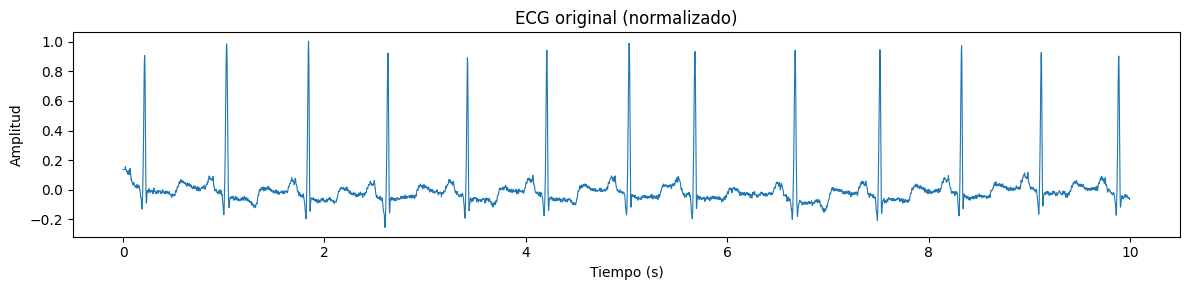

3600 muestras, 10.0 s


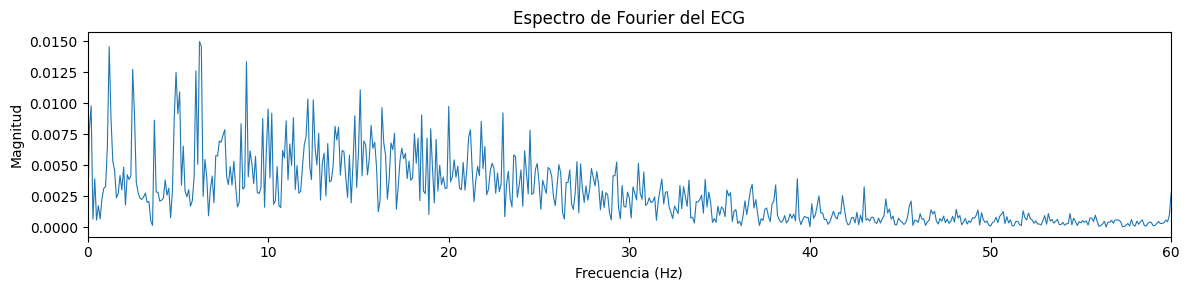

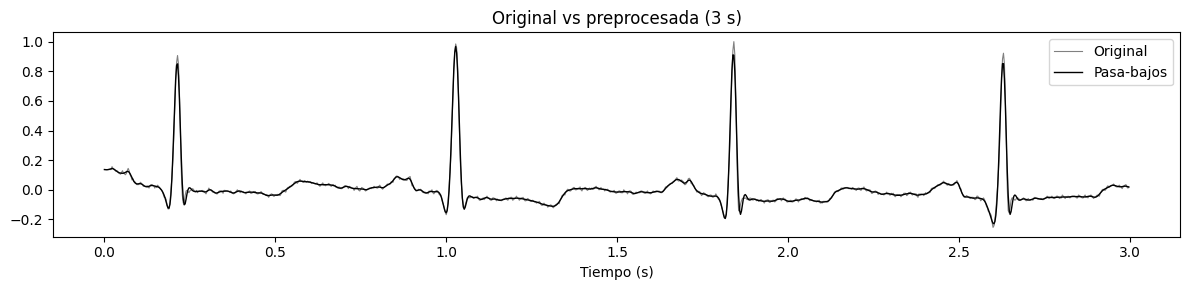

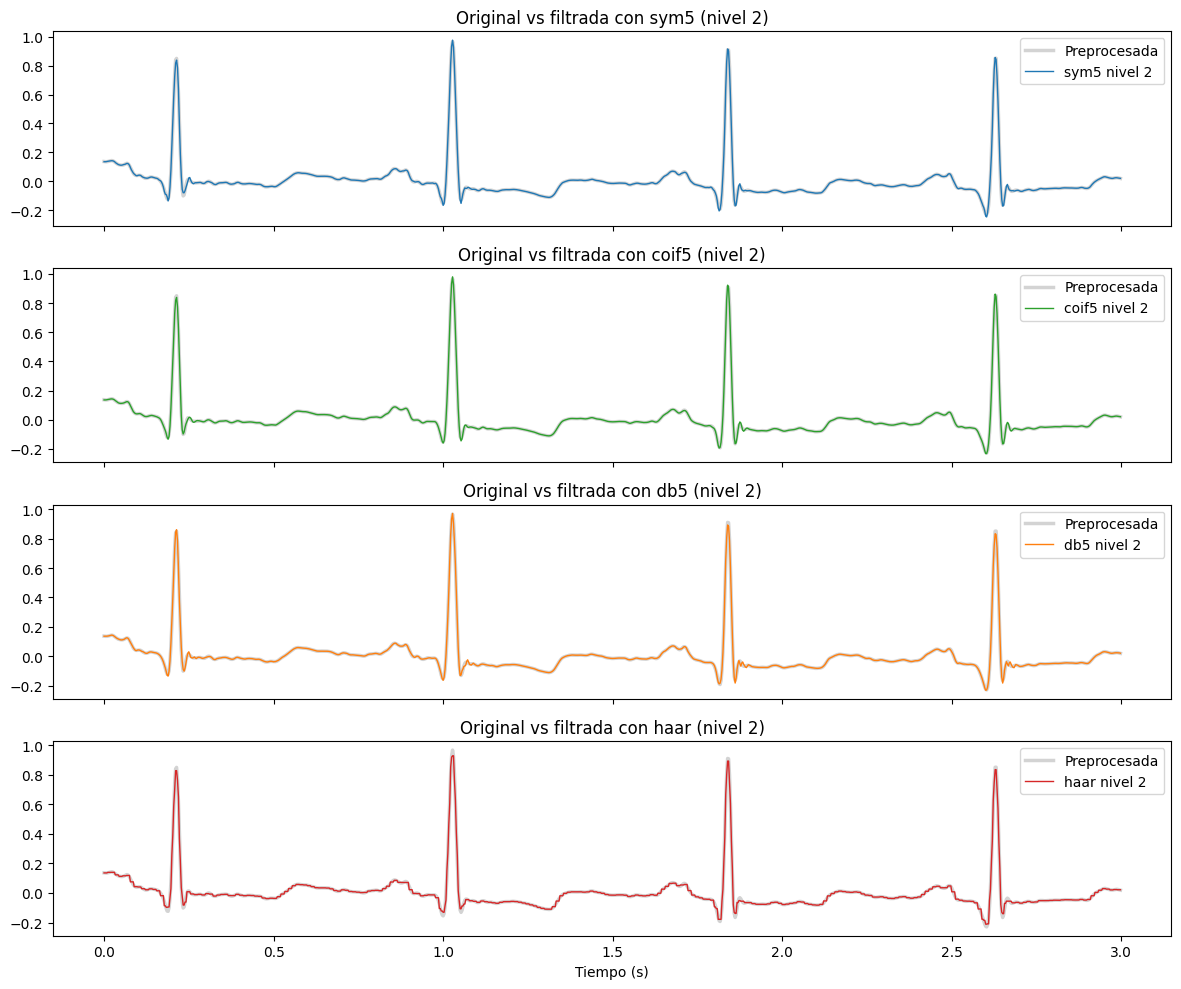

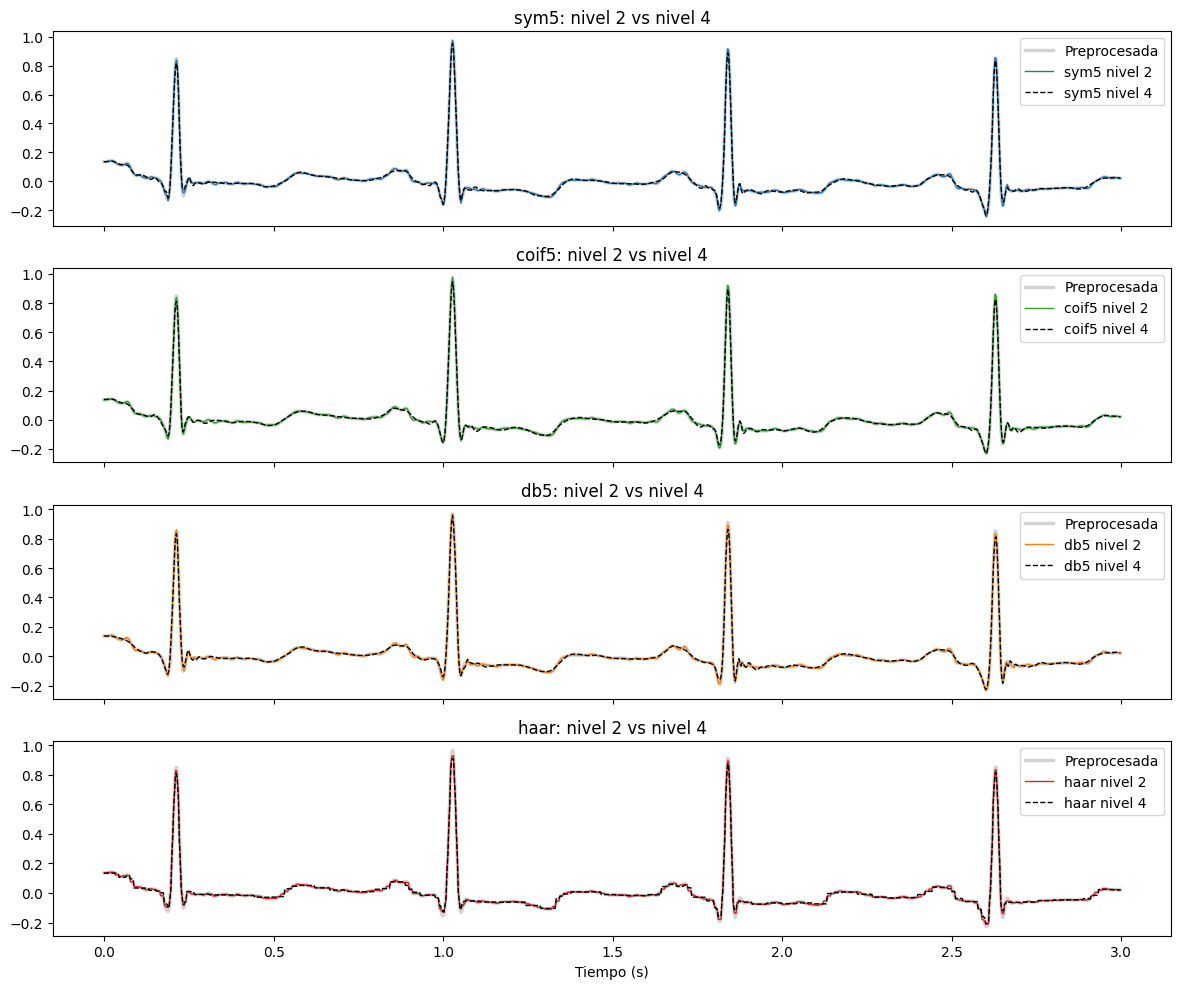

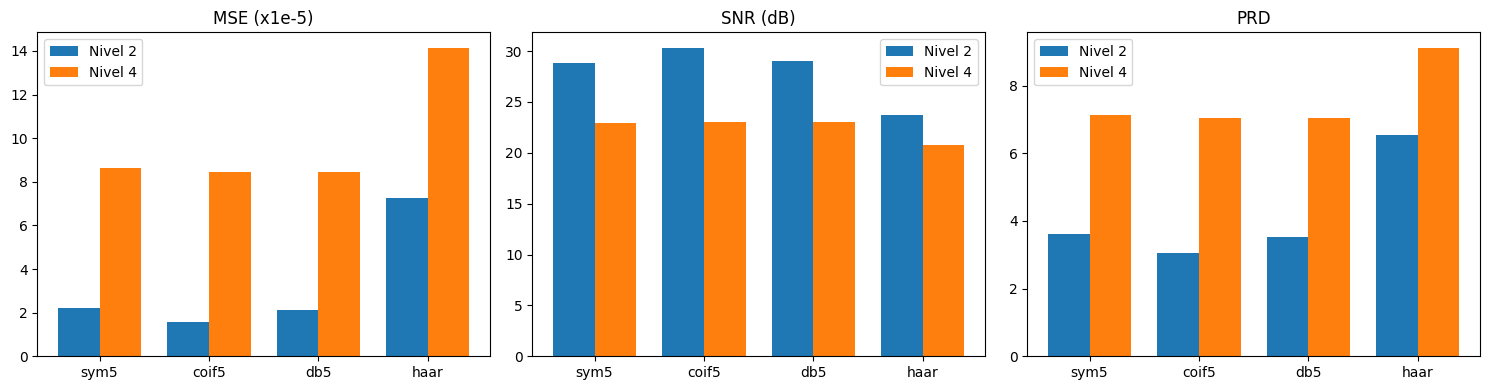

Las 3 mejores wavelets madre (nivel 2): ['coif5', 'db5', 'sym5']


,Wavelet,Lvl,MSE (x1e-5),SNR (dB),Correl.coeff.,PRD
2,coif5,2,1.578,30.326,1.000,3.046
4,db5,2,2.122,29.038,0.999,3.533
0,sym5,2,2.224,28.836,0.999,3.616
6,haar,2,7.245,23.706,0.998,6.527


In [6]:
!pip install PyWavelets
import os, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt                      # transformada wavelet
from scipy.signal import butter, filtfilt

os.makedirs("h2", exist_ok=True)

NOMBRE_ARCHIVO = "100_ekg.csv"
print("Archivo a usar:", NOMBRE_ARCHIVO)


df = pd.read_csv(NOMBRE_ARCHIVO)
df.columns = [c.strip().strip("'\"") for c in df.columns]      # limpia comillas en los nombres
df = df.apply(pd.to_numeric, errors="coerce").dropna(how="all")  # deja solo datos numéricos
print("Columnas:", df.columns.tolist())
df.head()

COLUMNA  = "MLII"   # nombre de la columna del ECG (mírala en la celda anterior)
FS       = 360      # frecuencia de muestreo en Hz
DURACION = 10       # segundos a analizar

if COLUMNA not in df.columns:
    raise ValueError(f"No existe la columna '{COLUMNA}'. Las columnas son: {df.columns.tolist()}")

x = df[COLUMNA].dropna().values[: int(FS * DURACION)]
x = x - np.mean(x)                 # quita el nivel DC
senal = x / np.max(np.abs(x))      # normaliza a [-1, 1]
t = np.arange(len(senal)) / FS

plt.figure(figsize=(12, 3))
plt.plot(t, senal, lw=0.8)
plt.title("ECG original (normalizado)"); plt.xlabel("Tiempo (s)"); plt.ylabel("Amplitud")
plt.tight_layout(); plt.savefig("h2/fig0_ecg_original.png", dpi=150); plt.show()
print(f"{len(senal)} muestras, {len(senal)/FS:.1f} s")

espectro = np.abs(np.fft.rfft(senal)) / len(senal)
freqs = np.fft.rfftfreq(len(senal), 1 / FS)

plt.figure(figsize=(12, 3))
plt.plot(freqs, espectro, lw=0.8)
plt.xlim(0, 60)
plt.title("Espectro de Fourier del ECG"); plt.xlabel("Frecuencia (Hz)"); plt.ylabel("Magnitud")
plt.tight_layout(); plt.savefig("h2/fig1_fourier.png", dpi=150); plt.show()

FC_PASABAJOS = 40   # Hz

def pasabajos(x, fc=FC_PASABAJOS, fs=FS, orden=4):
    b, a = butter(orden, fc / (fs / 2), btype="low")
    return filtfilt(b, a, x)

pre = pasabajos(senal)

plt.figure(figsize=(12, 3))
plt.plot(t[:3*FS], senal[:3*FS], color="gray", lw=0.8, label="Original")
plt.plot(t[:3*FS], pre[:3*FS], color="black", lw=1, label="Pasa-bajos")
plt.legend(); plt.title("Original vs preprocesada (3 s)"); plt.xlabel("Tiempo (s)")
plt.tight_layout(); plt.savefig("h2/fig2_preprocesada.png", dpi=150); plt.show()

sigma = np.median(np.abs(pywt.wavedec(senal, "db1", level=1)[-1])) / 0.6745
umbral = sigma * np.sqrt(2 * np.log(len(senal)))

def filtrar_wavelet(x, wavelet, nivel):
    coefs = pywt.wavedec(x, wavelet, level=nivel)
    coefs[1:] = [pywt.threshold(c, umbral, mode="soft") for c in coefs[1:]]
    return pywt.waverec(coefs, wavelet)[: len(x)]

def metricas(ref, filt):
    err = ref - filt
    mse  = np.mean(err ** 2)
    snr  = 10 * np.log10(np.sum(ref ** 2) / np.sum(err ** 2))
    corr = np.corrcoef(ref, filt)[0, 1]
    prd  = 100 * np.sqrt(np.sum(err ** 2) / np.sum(ref ** 2))
    return mse, snr, corr, prd


WAVELETS = ["sym5", "coif5", "db5", "haar"]
NIVELES  = [2, 4]

filas, salidas = [], {}
for w in WAVELETS:
    for n in NIVELES:
        f = filtrar_wavelet(pre, w, n)
        salidas[(w, n)] = f
        mse, snr, corr, prd = metricas(pre, f)   # se compara contra la señal preprocesada
        filas.append({"Wavelet": w, "Lvl": n, "MSE (x1e-5)": mse * 1e5,
                      "SNR (dB)": snr, "Correl.coeff.": corr, "PRD": prd})

tabla = pd.DataFrame(filas)
tabla.to_csv("h2/tabla_resultados.csv", index=False)
tabla.round(3)

colores = {"sym5": "tab:blue", "coif5": "tab:green", "db5": "tab:orange", "haar": "tab:red"}
seg = slice(0, 3 * FS)

fig, axs = plt.subplots(len(WAVELETS), 1, figsize=(12, 10), sharex=True)
for ax, w in zip(axs, WAVELETS):
    ax.plot(t[seg], pre[seg], color="lightgray", lw=2.5, label="Preprocesada")
    ax.plot(t[seg], salidas[(w, 2)][seg], color=colores[w], lw=1, label=f"{w} nivel 2")
    ax.set_title(f"Original vs filtrada con {w} (nivel 2)"); ax.legend(loc="upper right")
axs[-1].set_xlabel("Tiempo (s)")
plt.tight_layout(); plt.savefig("h2/fig3_original_vs_filtrada.png", dpi=150); plt.show()

fig, axs = plt.subplots(len(WAVELETS), 1, figsize=(12, 10), sharex=True)
for ax, w in zip(axs, WAVELETS):
    ax.plot(t[seg], pre[seg], color="lightgray", lw=2.5, label="Preprocesada")
    ax.plot(t[seg], salidas[(w, 2)][seg], color=colores[w], lw=1, label=f"{w} nivel 2")
    ax.plot(t[seg], salidas[(w, 4)][seg], "--", color="black", lw=1, label=f"{w} nivel 4")
    ax.set_title(f"{w}: nivel 2 vs nivel 4"); ax.legend(loc="upper right")
axs[-1].set_xlabel("Tiempo (s)")
plt.tight_layout(); plt.savefig("h2/fig4_nivel2_vs_nivel4.png", dpi=150); plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
xpos = np.arange(len(WAVELETS)); ancho = 0.38
for ax, col in zip(axs, ["MSE (x1e-5)", "SNR (dB)", "PRD"]):
    for i, n in enumerate(NIVELES):
        vals = [tabla[(tabla.Wavelet == w) & (tabla.Lvl == n)][col].values[0] for w in WAVELETS]
        ax.bar(xpos + (i - 0.5) * ancho, vals, ancho, label=f"Nivel {n}")
    ax.set_xticks(xpos); ax.set_xticklabels(WAVELETS); ax.set_title(col); ax.legend()
plt.tight_layout(); plt.savefig("h2/fig5_metricas.png", dpi=150); plt.show()

n2 = tabla[tabla.Lvl == 2].sort_values("MSE (x1e-5)")
mejores = [w for w in n2.Wavelet if w != "haar"][:3]
print("Las 3 mejores wavelets madre (nivel 2):", mejores)
n2.round(3)
